## Notebook 7: AC Electricity Consumption, Downscaling

In [1]:
import os
os.environ["CITY"] = "genova"   # pick the city here

In [2]:
# Generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# Choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: genova  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim


In [3]:
# city config + file paths from YAML 
cfg = C.get("cfg", {})                      # full YAML for the selected city
SLUG = cfg.get("slug", SLUG).lower()        
CITY = cfg.get("city_name", CITY)

paths    = cfg.get("files", {})             # {gvi_csv, lcz_candidates, cooling_coeffs_csv, ...}
osm_cfg  = cfg.get("osm", {})               # OSM settings used later in NB5
trees_cfg = cfg.get("trees", {})            # TARGET/CAP for NB5
urbclim   = cfg.get("urbclim", {})          # UrbClim folder/settings for NB5

lcz_candidates = [P(p) for p in paths.get("lcz_candidates", [])]
gvi_path = P(paths.get("gvi_csv", ""))

# FUA geopackage written in NB2 
fua_gpkg = Path(paths.get("fua_gpkg", f"{OUT}/{SLUG}_fua.gpkg"))

cool_csv = P(paths.get("cooling_coeffs_csv", ""))

# checks
print("SLUG/CITY:", SLUG, CITY)
print("GVI CSV:  ", gvi_path)
print("LCZ cand: ", [str(p) for p in lcz_candidates])
print("FUA GPKG: ", fua_gpkg)
print("Cooling CSV:", cool_csv)

SLUG/CITY: genova Genova
GVI CSV:   /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/gviGenova/gvi_Genova.csv
LCZ cand:  ['/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/LCZ/lcz_filter_v3.tif', '/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/LCZ/lcz_v3.tif']
FUA GPKG:  /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_fua.gpkg
Cooling CSV: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/CoolingEff/outer_2_wbgt_max.csv


**Loading from before**

In [4]:
# helper: picking first existing path from candidates 
def _first_existing(*cands, glob_pattern=None):
    for p in cands:
        p = Path(p)
        if p.exists():
            return p
    if glob_pattern is not None:
        hits = sorted(Path(OUT).glob(glob_pattern))
        if len(hits) == 1:
            return hits[0]
    return None

In [5]:
import numpy as np
import rasterio as rio
import geopandas as gpd
import pandas as pd
from pathlib import Path

# FUA / Regions paths
fua_gpkg = Path(paths.get("fua_gpkg", OUT / f"{SLUG}_fua.gpkg"))
fua_gpkg = _first_existing(fua_gpkg, OUT / "fua.gpkg", glob_pattern="*_fua.gpkg")
assert fua_gpkg and fua_gpkg.exists(), "Missing FUA geopackage."

regions_gpkg = Path(paths.get("regions_gpkg", OUT / f"{SLUG}_regions.gpkg"))
regions_gpkg = _first_existing(regions_gpkg, OUT / "regions.gpkg", glob_pattern="*_regions.gpkg")
assert regions_gpkg and regions_gpkg.exists(), "Missing regions geopackage."

muni_on_ref_tif = Path(paths.get("muni_on_ref_tif", OUT / f"{SLUG}_muni_on_ref.tif"))
muni_on_ref_tif = _first_existing(muni_on_ref_tif, OUT / "muni_on_ref.tif", glob_pattern="*_muni_on_ref.tif")
assert muni_on_ref_tif and muni_on_ref_tif.exists(), "Missing muni_on_ref.tif (save it in NB5)."

# LUTs
muni_lut_csv = Path(paths.get("muni_lut_csv", OUT / f"{SLUG}_muni_lut.csv"))
muni_lut_csv = _first_existing(muni_lut_csv, OUT / "muni_lut.csv", glob_pattern="*_muni_lut.csv")
assert muni_lut_csv and muni_lut_csv.exists(), "Missing muni_lut.csv (save it in NB5)."

lut = (
    pd.read_csv(muni_lut_csv)
    .assign(muni_id=lambda d: d["muni_id"].astype(int))
    .sort_values("muni_id")
)
print("Using muni LUT:", muni_lut_csv.name, "| rows:", len(lut))

cap_gpkg = Path(paths.get("cap_gpkg", OUT / f"{SLUG}_cap.gpkg"))
cap_gpkg = _first_existing(cap_gpkg, OUT / "cap.gpkg", glob_pattern="*_cap.gpkg")
assert cap_gpkg and cap_gpkg.exists(), "Missing CAP geopackage."

cap_lut_csv = Path(paths.get("cap_lut_csv", OUT / f"{SLUG}_cap_lut.csv"))
cap_lut_csv = _first_existing(cap_lut_csv, OUT / "cap_lut.csv", glob_pattern="*_cap_lut.csv")
assert cap_lut_csv and cap_lut_csv.exists(), "Missing cap_lut.csv (save it in NB6)."

cap_ref_lut = (pd.read_csv(cap_lut_csv).astype({"cap_id": int, "cap5": str}).drop_duplicates())
print("Using CAP LUT:", cap_lut_csv.name, "| rows:", len(cap_ref_lut))

cap_wgs84_lut_path = Path(paths.get("cap_wgs84_lut", OUT / f"{SLUG}_cap_wgs84_lut.csv"))
cap_wgs84_lut_path = _first_existing(cap_wgs84_lut_path, OUT / "cap_wgs84_lut.csv", glob_pattern="*_cap_wgs84_lut.csv")
cap_wgs84_lut_df = None
if cap_wgs84_lut_path and cap_wgs84_lut_path.exists():
    cap_wgs84_lut_df = (pd.read_csv(cap_wgs84_lut_path).astype({"cap_id": int, "cap5": str}).drop_duplicates())
    print("Using CAP WGS84 LUT:", cap_wgs84_lut_path.name)

# Reference grid + city mask
tmpl_path = INT / "template_ref.tif" # T2M ref grid
mask_tif = INT / "city_mask.tif" # boolean mask on that grid
with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
HGT, WDT = ref_meta["height"], ref_meta["width"]
with rio.open(mask_tif) as src:
    CITY_MASK = src.read(1).astype(bool)
ref_data = np.where(CITY_MASK, 0.0, np.nan)
HAZ_MASK = np.isfinite(ref_data)

# Hot-days stack
# T2M hazard stack on ref grid (mean daily T2M per year)
t2m_npz_path = _first_existing(
    INT / f"t2m_hazard_2030_2100_{SLUG}.npz",
    INT / "t2m_hazard_2030_2100.npz",
    glob_pattern="t2m_hazard_2030_2100*.npz"
)
assert t2m_npz_path and t2m_npz_path.exists(), "Missing T2M hazard .npz (run NB3)."

npz = np.load(t2m_npz_path)
YEARS = npz["years"].astype(int) # (n_years,)
DATA = npz["data"].astype("float32") # (n_years, HGT, WDT)
assert DATA.shape[1:] == (HGT, WDT), f"T2M hazard grid {DATA.shape[1:]} != ref grid {(HGT, WDT)}"
H2050 = DATA[list(YEARS).index(2050)]
print("Loaded T2M hazard:", t2m_npz_path.name, "| years:", YEARS.min(), "→", YEARS.max())

# AC coverage
# loading AC targets (city mean shares) produced by NB5 
targets_path = INT / f"ac_city_targets_{SLUG}.csv"
t = pd.read_csv(targets_path)
ac_city_by_year = dict(zip(t["year"].astype(int), t["ac_share"].astype(float)))

# loading AC coverage maps (CAP-based maps) produced by NB5 
cov_path = INT / f"ac_coverage_maps_{SLUG}.npz"
z = np.load(cov_path)
YEARS_COV = z["YEARS_AC"].astype(int).tolist()
year_to_k = {y: i for i, y in enumerate(YEARS_COV)}

coverage_base_3d = z["coverage_base_3d"].astype("float32")
coverage_policy_3d = z["coverage_policy_3d"].astype("float32")

def cov_base_for_year(y: int) -> np.ndarray:
    return coverage_base_3d[year_to_k[int(y)]]

def cov_policy_for_year(y: int) -> np.ndarray:
    return coverage_policy_3d[year_to_k[int(y)]]

# Population / CAP rasters
def _load_pop_on_ref(INT, SLUG, HGT, WDT):
    pop_npz_path = _first_existing(
        INT / f"pop_on_ref_{SLUG}.npz",
        INT / "pop_on_ref.npz",
        glob_pattern="pop_on_ref*.npz"
    )
    if pop_npz_path and pop_npz_path.exists():
        pop = np.load(pop_npz_path)["pop"].astype("float32")
    else:
        # fallback to GeoTIFF saved in NB5
        with rio.open(INT / "pop_on_ref.tif") as src:
            pop = src.read(1).astype("float32")
            assert (src.height, src.width) == (HGT, WDT), "pop_on_ref.tif grid mismatch."
    assert pop.shape == (HGT, WDT), f"pop_on_ref shape {pop.shape} != {(HGT, WDT)}"
    return pop

def _load_age_on_ref(INT, SLUG, HGT, WDT):
    age_npz_path = _first_existing(
        INT / f"age_on_ref_{SLUG}.npz",
        INT / "age_on_ref.npz",
        glob_pattern="age_on_ref*.npz"
    )
    if age_npz_path and age_npz_path.exists():
        d = np.load(age_npz_path)
        age = {"<15": d["lt15"].astype("float32"), "15-64": d["a15_64"].astype("float32"), "65+": d["g65"].astype("float32")}
    else:
        # fallback to per-band GeoTIFFs saved in NB5
        age = {}
        with rio.open(INT / "age_lt15_on_ref.tif") as s:
            age["<15"] = s.read(1).astype("float32")
        with rio.open(INT / "age_15_64_on_ref.tif") as s:
            age["15-64"] = s.read(1).astype("float32")
        with rio.open(INT / "age_65p_on_ref.tif") as s:
            age["65+"] = s.read(1).astype("float32")
    for k,v in age.items():
        assert v.shape == (HGT, WDT), f"age {k} shape {v.shape} != {(HGT, WDT)}"
    return age

# using them
pop_on_ref = _load_pop_on_ref(INT, SLUG, HGT, WDT)
age_on_ref = _load_age_on_ref(INT, SLUG, HGT, WDT)

print(
    "Loaded exposure:",
    f"\n pop_on_ref: {pop_on_ref.shape}, sum={np.nansum(pop_on_ref):.0f}",
    f"\n age lt15: {age_on_ref['<15'].shape}, sum={np.nansum(age_on_ref['<15']):.0f}",
    f"\n age 15-64: {age_on_ref['15-64'].shape}, sum={np.nansum(age_on_ref['15-64']):.0f}",
    f"\n age 65+: {age_on_ref['65+'].shape}, sum={np.nansum(age_on_ref['65+']):.0f}",
)

# CAP raster on ref grid
def _load_cap_on_ref(INT, SLUG, HGT, WDT):
    cap_npz_path = _first_existing(
        INT / f"cap_on_ref_{SLUG}.npz",
        INT / "cap_on_ref.npz",
        glob_pattern="cap_on_ref*.npz"
    )
    if cap_npz_path and cap_npz_path.exists():
        cap = np.load(cap_npz_path)["cap_on_ref"].astype("int32")
    else:
        # fallback to GeoTIFF written in NB6
        with rio.open(INT / f"cap_on_ref_{SLUG}.tif") as src:
            cap = src.read(1).astype("int32")
            assert (src.height, src.width) == (HGT, WDT), "cap_on_ref.tif grid mismatch."
    assert cap.shape == (HGT, WDT), f"cap_on_ref shape {cap.shape} != {(HGT, WDT)}"
    return cap

cap_on_ref = _load_cap_on_ref(INT, SLUG, HGT, WDT)

# Optional: CAP_MASK from coverage NPZ if present, else derive from CAP raster
if "CAP_MASK" in z.files:
    CAP_MASK = z["CAP_MASK"].astype(bool)
else:
    CAP_MASK = (CITY_MASK & (cap_on_ref > 0))

# Vectors
fua = gpd.read_file(fua_gpkg).to_crs("EPSG:4326")
regions = gpd.read_file(regions_gpkg, layer="regions").set_crs("EPSG:4326")
muni = gpd.read_file(regions_gpkg, layer="muni").set_crs("EPSG:4326")

with rio.open(muni_on_ref_tif) as src:
    muni_on_ref = src.read(1).astype("int32")
    assert (src.crs == ref_meta["crs"]) and (src.transform == ref_meta["transform"]), "Grid mismatch."

print("Loaded regions:", len(regions), "polygons; muni_on_ref shape:", muni_on_ref.shape)
print("Unique muni IDs on grid (>=0):", int(np.unique(muni_on_ref[muni_on_ref >= 0]).size))

cap_ref = gpd.read_file(cap_gpkg, layer="cap").to_crs(ref_meta["crs"])
cap_4326 = gpd.read_file(cap_gpkg, layer="cap_wgs84").to_crs("EPSG:4326")

print(
    "Loaded:",
    "\n FUA:", fua_gpkg.name,
    "\n Regions:", regions_gpkg.name,
    "\n muni_on_ref:", muni_on_ref_tif.name, muni_on_ref.shape,
    "\n CAPs:", cap_gpkg.name
)

Using muni LUT: genova_muni_lut.csv | rows: 10
Using CAP LUT: genova_cap_lut.csv | rows: 70
Using CAP WGS84 LUT: genova_cap_wgs84_lut.csv
Loaded T2M hazard: t2m_hazard_2030_2100_genova.npz | years: 2030 → 2050
Loaded exposure: 
 pop_on_ref: (251, 251), sum=576550 
 age lt15: (251, 251), sum=53034 
 age 15-64: (251, 251), sum=334769 
 age 65+: (251, 251), sum=188747
Loaded regions: 10 polygons; muni_on_ref shape: (251, 251)
Unique muni IDs on grid (>=0): 10
Loaded: 
 FUA: genova_fua.gpkg 
 Regions: genova_regions.gpkg 
 muni_on_ref: genova_muni_on_ref.tif (251, 251) 
 CAPs: genova_cap.gpkg


<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Parametrisation of the AC costs: using the gridded AC data : divide TWh layers by pop layers, convert units to get average AC electricity use (kWh / capita + year)
</blockquote>

**Loading the data**

In [6]:
# AC kWh per AC-user (city) from NUTS CSV (no NetCDF / no pixel)
import pandas as pd
import numpy as np
import re

ac_cfg = cfg.get("ac", {})
kwh_path = P(ac_cfg.get("kwh_file", ""))
assert kwh_path.exists(), f"Missing AC kWh CSV: {kwh_path}"

# settings from YAML
ssp_choice = int(ac_cfg.get("ssp", 2))
years_interest = list(ac_cfg.get("years", [2030, 2040, 2050]))
nuts_id = ac_cfg.get("nuts_id", None)
assert nuts_id, "cfg['ac']['nuts_id'] missing (e.g. 'ITI43')."

cols = ac_cfg.get("kwh_columns", {}) or {}
COL_ID = cols.get("id", "NUTS_ID")
COL_SSP = cols.get("scenario", "Scenario")
COL_YEAR = cols.get("year", "year")
COL_VAL = cols.get("value", "value")

df = pd.read_csv(kwh_path)

# basic column check
need = [COL_ID, COL_SSP, COL_YEAR, COL_VAL]
missing = [c for c in need if c not in df.columns]
assert not missing, f"Missing columns in {kwh_path.name}: {missing}. Found: {list(df.columns)}"

# normalising scenario to an integer SSP number when possible
def _ssp_to_int(x):
    s = str(x)
    m = re.search(r"(\d+)", s)
    return int(m.group(1)) if m else None

df = df.copy()
df["_ssp_int"] = df[COL_SSP].map(_ssp_to_int)
df[COL_YEAR] = pd.to_numeric(df[COL_YEAR], errors="coerce")
df[COL_VAL] = pd.to_numeric(df[COL_VAL], errors="coerce").replace([-999, -9999], np.nan)

# filter
sub = df[(df[COL_ID].astype(str) == str(nuts_id)) & (df["_ssp_int"] == ssp_choice)].dropna(subset=[COL_YEAR, COL_VAL])
assert len(sub) > 0, (
    f"No rows found for NUTS_ID={nuts_id} and SSP={ssp_choice} in {kwh_path.name}. "
    f"Check values in columns {COL_ID} / {COL_SSP}."
)

# if duplicates exist, take mean per year 
series = (sub.groupby(sub[COL_YEAR].astype(int))[COL_VAL].mean()).to_dict()

# build dict for requested years
missing_years = [y for y in years_interest if int(y) not in series]
assert not missing_years, f"Missing years in AC kWh CSV for {nuts_id}, SSP{ssp_choice}: {missing_years}"

per_user_city_by_year = {int(y): float(series[int(y)]) for y in years_interest}
per_user_city = float(per_user_city_by_year[max(years_interest)])

print("AC per-AC-user from NUTS CSV (kWh/user/yr):")
for y in years_interest:
    print(f" {y}: {per_user_city_by_year[int(y)]:.3f}")

# save CSV for NB8 
ac_city_series = pd.DataFrame({
    "year": years_interest,
    "kwh_per_ac_user_city": [per_user_city_by_year[int(y)] for y in years_interest],
})

out_csv = INT / f"ac_per_user_city_{SLUG}.csv"
ac_city_series.to_csv(out_csv, index=False)
print("Saved:", out_csv)

AC per-AC-user from NUTS CSV (kWh/user/yr):
 2030: 523.570
 2040: 523.570
 2050: 382.303
Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/ac_per_user_city_genova.csv


**Downscaling the AC electricity consumption at the CAP level**: based not on the income but on the hazard level

**Question of the shape**: message of Giacomo: following the approach we used to create a variation across CAPs from a single datapoint for AC, also create a variation in consumption. The data point is already in per AC-user, so we just need to create a spread that follows a normal distribution with mean = the pixel value and proportional to the local heat levels

In [7]:
import numpy as np
import pandas as pd

# We now rely on per-year dict from the NetCDF step
assert ("per_user_city_by_year" in globals() and isinstance(per_user_city_by_year, dict) and len(per_user_city_by_year) > 0), \
 "per_user_city_by_year must be defined by the NetCDF/FUA selection cell."

years_interest = [2030, 2040, 2050]
pop_grid = pop_on_ref
cap_ids = cap_on_ref

def _get_H_for_year(year):
    if year not in YEARS:
        raise KeyError(f"Year {year} not found in T2M YEARS: {list(YEARS)}")
    idx = list(YEARS).index(int(year))
    return DATA[idx, :, :]

def _cov_for_year(year):
    """ Return AC coverage map for a given year from the NB5 3D maps.
    NB5 already did the year-specific calibration, so no extra rescaling here.
    """
    year = int(year)
    if year not in year_to_k:
        raise KeyError(f"Year {year} not in YEARS_COV (from NB5): {YEARS_COV}")
    base = cov_base_for_year(year).astype("float32")
    return np.clip(base, 0.0, 1.0).astype("float32")

rng = np.random.default_rng(42)
sigma0 = 0.20 # base dispersion (20% of mean)
gamma = 1.0 # how strongly dispersion scales with hazard ratio

**CAP Maps or tables:**

In [8]:
# drawing ONE eps per CAP ONCE, and reuse it for all years 
# Use 2030 only to define the CAP set (ids) consistently.
H0 = _get_H_for_year(2030)
CAP_PIX0 = CITY_MASK & np.isfinite(H0) & (cap_ids > 0)
valid0 = CAP_PIX0 & np.isfinite(pop_grid)

dfH0 = pd.DataFrame({
    "cap_id": cap_ids[valid0].ravel().astype(int),
    "pop": pop_grid[valid0].ravel().astype(float),
    "H": H0[valid0].ravel().astype(float),
})

def _wavg_pop(g):
    w = g["pop"].to_numpy()
    x = g["H"].to_numpy()
    return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

cap_ids_all = (dfH0["cap_id"].drop_duplicates().sort_values().to_numpy())
eps_by_cap = dict(zip(cap_ids_all, rng.normal(0.0, 1.0, size=len(cap_ids_all))))


=== Year 2030 ===
AC share from map (city pop-weighted): 0.427
AC share from NB5 (target): 0.427
Per-user mean (city): 523.5695190429688
AC share from map:  0.4262761175632477
City total GWh:  128.67736

=== Year 2040 ===
AC share from map (city pop-weighted): 0.427
AC share from NB5 (target): 0.427
Per-user mean (city): 523.569580078125
AC share from map:  0.4262761175632477
City total GWh:  128.67736

=== Year 2050 ===
AC share from map (city pop-weighted): 0.471
AC share from NB5 (target): 0.471
Per-user mean (city): 382.3033752441406
AC share from map:  0.4696764647960663
City total GWh:  103.524632


,year,ac_share_city,ac_share_from_map,per_user_city_input,per_user_city_realized,city_total_GWh
0,2030,0.427152,0.426276,523.569580,523.569519,128.677360
1,2040,0.427152,0.426276,523.569580,523.569580,128.677360
2,2050,0.470641,0.469676,382.303345,382.303375,103.524632



==== CAP-level results for year 2030 ====
City pop: 575,368
City AC users: 245,769 (AC share ≈ 0.427)
City total AC electricity: 128.677 GWh/yr
City per-AC-user mean (users-weighted): 523.569511 kWh/user/yr

Top 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,29,0.585556,625.848877,5134.223732,1.881535e+06,366.469300,2030
1,34,0.546445,613.674316,8396.484589,2.815670e+06,335.339172,2030
2,67,0.581309,567.923157,9086.437431,2.999786e+06,330.138855,2030
3,32,0.590609,553.381897,12004.961136,3.923612e+06,326.832582,2030
4,50,0.565743,577.695618,19371.714581,6.331202e+06,326.827117,2030
5,26,0.539972,600.396240,11437.443077,3.707983e+06,324.196871,2030
6,6,0.487691,626.511353,9888.495211,3.021368e+06,305.543793,2030
7,56,0.507686,601.785645,9679.885061,2.957381e+06,305.518189,2030
8,66,0.557581,543.770569,6568.575960,1.991566e+06,303.196015,2030
9,57,0.522803,578.747437,7868.937939,2.380911e+06,302.570832,2030


Bottom 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,53,0.251243,434.351471,24408.305624,2.663625e+06,109.127815,2030
1,58,0.292281,446.212585,26751.984914,3.488983e+06,130.419586,2030
2,61,0.241391,544.527100,11082.733579,1.456758e+06,131.443909,2030
3,52,0.261636,506.712799,11853.539373,1.571476e+06,132.574448,2030
4,60,0.269958,532.505493,16404.380937,2.358201e+06,143.754349,2030
5,7,0.481903,298.424744,2922.532556,4.202950e+05,143.811920,2030
6,37,0.330898,453.339050,8133.884874,1.220156e+06,150.009033,2030
7,41,0.316581,480.767365,17059.041387,2.596416e+06,152.201752,2030
8,42,0.277129,571.536011,7441.681828,1.178682e+06,158.389176,2030
9,54,0.379634,427.755707,20192.516093,3.279077e+06,162.390702,2030



Top 10 CAPs by kwh_cap — Total kWh, 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,55,0.431306,589.387146,26772.932431,6.805842e+06,254.206054,2030
1,50,0.565743,577.695618,19371.714581,6.331202e+06,326.827117,2030
2,47,0.600371,480.494385,21811.609401,6.292101e+06,288.474883,2030
3,51,0.342412,643.191284,25758.312021,5.672925e+06,220.236665,2030
4,48,0.611259,467.342285,17133.486430,4.894473e+06,285.667082,2030
5,45,0.415348,562.831299,17501.887853,4.091427e+06,233.770629,2030
6,35,0.462967,514.063599,16662.425335,3.965563e+06,237.994353,2030
7,32,0.590609,553.381897,12004.961136,3.923612e+06,326.832582,2030
8,49,0.530851,434.289520,16132.890423,3.719328e+06,230.543182,2030
9,26,0.539972,600.396240,11437.443077,3.707983e+06,324.196871,2030


Bottom 10 CAPs by kwh_cap — Total kWh, 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,11,0.484211,530.561340,5.239209,1.345971e+03,256.903387,2030
1,1,0.480868,554.100342,10.040666,2.675327e+03,266.449158,2030
2,5,0.492983,604.800415,29.122448,8.683033e+03,298.156032,2030
3,12,0.483123,494.058990,535.889242,1.279122e+05,238.691467,2030
4,14,0.483761,517.557861,1271.717400,3.184051e+05,250.374100,2030
5,7,0.481903,298.424744,2922.532556,4.202950e+05,143.811920,2030
6,9,0.492066,371.335907,2592.257662,4.736618e+05,182.721710,2030
7,38,0.470064,638.262939,3241.327610,9.724777e+05,300.024506,2030
8,27,0.479581,586.513550,3631.617332,1.021504e+06,281.280852,2030
9,42,0.277129,571.536011,7441.681828,1.178682e+06,158.389176,2030


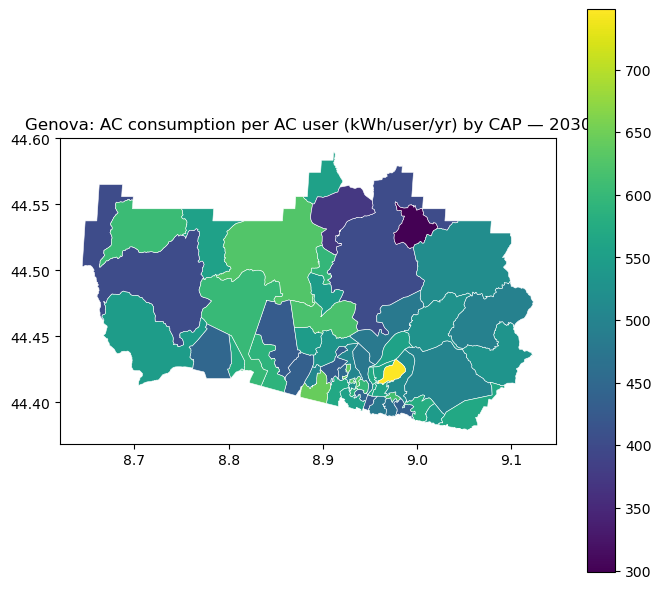

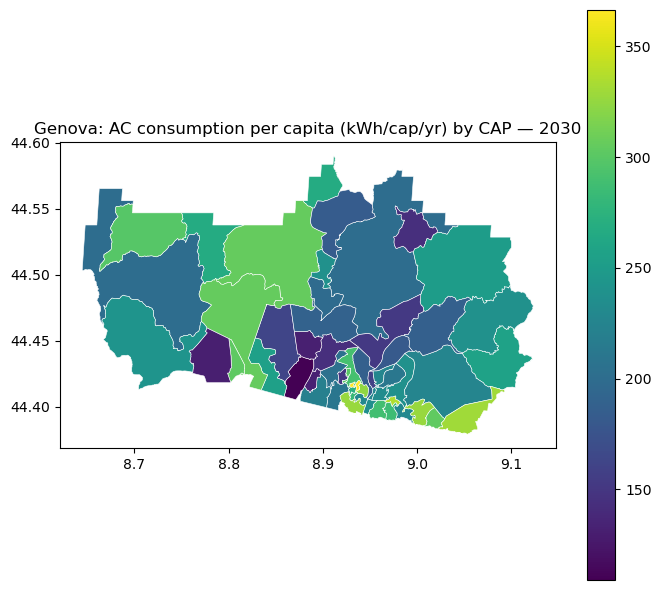


==== CAP-level results for year 2040 ====
City pop: 575,368
City AC users: 245,769 (AC share ≈ 0.427)
City total AC electricity: 128.677 GWh/yr
City per-AC-user mean (users-weighted): 523.569521 kWh/user/yr

Top 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,29,0.585556,625.948120,5134.223732,1.881834e+06,366.527403,2040
1,34,0.546445,613.637939,8396.484589,2.815503e+06,335.319274,2040
2,67,0.581309,568.087769,9086.437431,3.000656e+06,330.234558,2040
3,50,0.565743,577.746460,19371.714581,6.331759e+06,326.855895,2040
4,32,0.590609,553.419922,12004.961136,3.923882e+06,326.855011,2040
5,26,0.539972,600.493469,11437.443077,3.708584e+06,324.249390,2040
6,6,0.487691,626.423584,9888.495211,3.020945e+06,305.500976,2040
7,56,0.507686,601.733582,9679.885061,2.957125e+06,305.491760,2040
8,66,0.557581,543.822510,6568.575960,1.991756e+06,303.224976,2040
9,57,0.522803,578.716736,7868.937939,2.380785e+06,302.554779,2040


Bottom 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,53,0.251243,434.326447,24408.305624,2.663472e+06,109.121529,2040
1,58,0.292281,446.248016,26751.984914,3.489260e+06,130.429932,2040
2,61,0.241391,544.500122,11082.733579,1.456686e+06,131.437393,2040
3,52,0.261636,506.718384,11853.539373,1.571494e+06,132.575897,2040
4,60,0.269958,532.492676,16404.380937,2.358144e+06,143.750885,2040
5,7,0.481903,298.586273,2922.532556,4.205225e+05,143.889755,2040
6,37,0.330898,453.291321,8133.884874,1.220028e+06,149.993240,2040
7,41,0.316581,480.785553,17059.041387,2.596514e+06,152.207504,2040
8,42,0.277129,571.563965,7441.681828,1.178740e+06,158.396927,2040
9,54,0.379634,427.812195,20192.516093,3.279510e+06,162.412140,2040



Top 10 CAPs by kwh_cap — Total kWh, 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,55,0.431306,589.360046,26772.932431,6.805529e+06,254.194366,2040
1,50,0.565743,577.746460,19371.714581,6.331759e+06,326.855895,2040
2,47,0.600371,480.459991,21811.609401,6.291652e+06,288.454254,2040
3,51,0.342412,643.121399,25758.312021,5.672308e+06,220.212723,2040
4,48,0.611259,467.329651,17133.486430,4.894341e+06,285.659363,2040
5,45,0.415348,562.840759,17501.887853,4.091496e+06,233.774567,2040
6,35,0.462967,514.062378,16662.425335,3.965554e+06,237.993789,2040
7,32,0.590609,553.419922,12004.961136,3.923882e+06,326.855011,2040
8,49,0.530851,434.295135,16132.890423,3.719376e+06,230.546158,2040
9,26,0.539972,600.493469,11437.443077,3.708584e+06,324.249390,2040


Bottom 10 CAPs by kwh_cap — Total kWh, 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,11,0.484211,530.579407,5.239209,1.346016e+03,256.912147,2040
1,1,0.480868,554.069458,10.040666,2.675178e+03,266.434295,2040
2,5,0.492983,604.729858,29.122448,8.682020e+03,298.121245,2040
3,12,0.483123,493.981445,535.889242,1.278921e+05,238.654007,2040
4,14,0.483761,517.555725,1271.717400,3.184038e+05,250.373062,2040
5,7,0.481903,298.586273,2922.532556,4.205225e+05,143.889755,2040
6,9,0.492066,371.449127,2592.257662,4.738062e+05,182.777436,2040
7,38,0.470064,638.338257,3241.327610,9.725925e+05,300.059904,2040
8,27,0.479581,586.644043,3631.617332,1.021732e+06,281.343415,2040
9,42,0.277129,571.563965,7441.681828,1.178740e+06,158.396927,2040


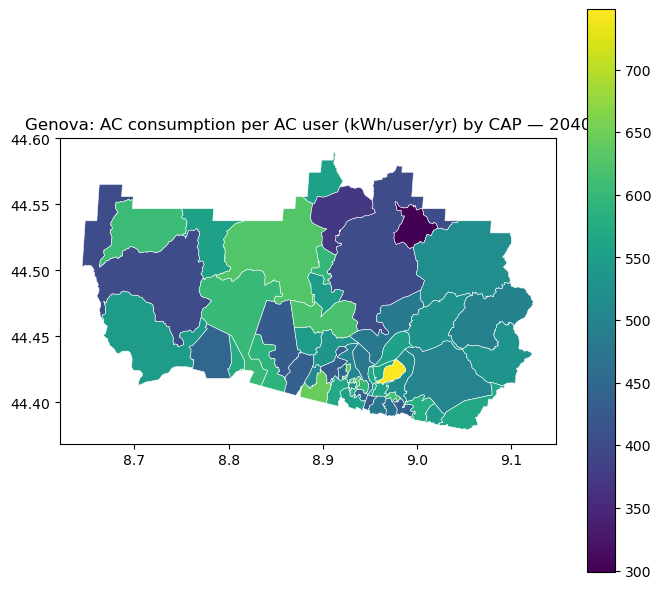

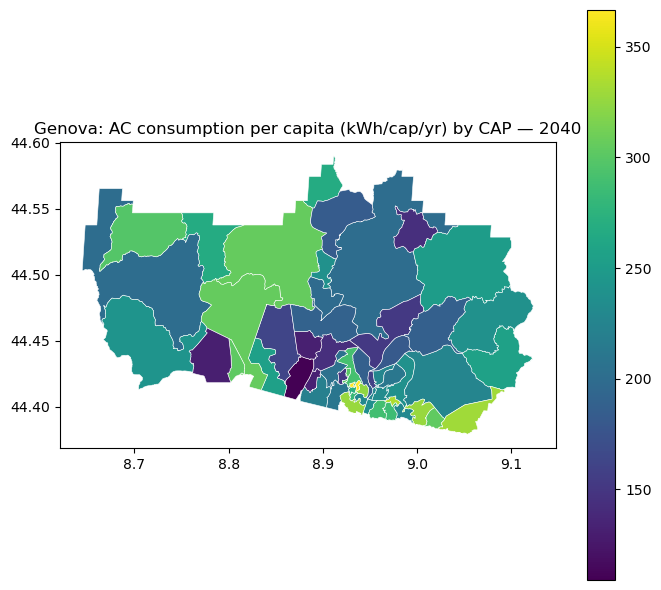


==== CAP-level results for year 2050 ====
City pop: 575,368
City AC users: 270,792 (AC share ≈ 0.471)
City total AC electricity: 103.525 GWh/yr
City per-AC-user mean (users-weighted): 382.303358 kWh/user/yr

Top 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,29,0.647311,457.172333,5134.223732,1.519384e+06,295.932496,2050
1,34,0.603690,448.044037,8396.484589,2.271079e+06,270.479736,2050
2,67,0.642574,414.987610,9086.437431,2.422993e+06,266.660432,2050
3,32,0.652947,404.147522,12004.961136,3.167953e+06,263.887024,2050
4,50,0.625213,421.924988,19371.714581,5.110124e+06,263.793091,2050
5,26,0.596470,438.582092,11437.443077,2.992049e+06,261.601226,2050
6,56,0.560462,439.325409,9679.885061,2.383432e+06,246.225189,2050
7,6,0.538161,457.306000,9888.495211,2.433601e+06,246.104278,2050
8,66,0.616110,397.152832,6568.575960,1.607264e+06,244.689867,2050
9,57,0.577322,422.542511,7868.937939,1.919573e+06,243.943085,2050


Bottom 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,53,0.274449,317.118713,24408.305624,2.124322e+06,87.032761,2050
1,58,0.320219,325.889221,26751.984914,2.791726e+06,104.355858,2050
2,61,0.263460,397.564301,11082.733579,1.160832e+06,104.742417,2050
3,52,0.286040,370.009735,11853.539373,1.254550e+06,105.837624,2050
4,60,0.295322,388.811188,16404.380937,1.883624e+06,114.824478,2050
5,7,0.531706,218.225220,2922.532556,3.391066e+05,116.031746,2050
6,37,0.363289,330.940491,8133.884874,9.779118e+05,120.226898,2050
7,41,0.347320,351.085754,17059.041387,2.080167e+06,121.939247,2050
8,42,0.303319,417.383087,7441.681828,9.421194e+05,126.600334,2050
9,54,0.417644,312.446167,20192.516093,2.634950e+06,130.491409,2050



Top 10 CAPs by kwh_cap — Total kWh, 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,55,0.475274,430.320587,26772.932431,5.475608e+06,204.520294,2050
1,50,0.625213,421.924988,19371.714581,5.110124e+06,263.793091,2050
2,47,0.663835,350.792725,21811.609401,5.079233e+06,232.868317,2050
3,51,0.376131,469.535919,25758.312021,4.549093e+06,176.606812,2050
4,48,0.675978,341.226929,17133.486430,3.952041e+06,230.661819,2050
5,45,0.457476,410.994904,17501.887853,3.290710e+06,188.020294,2050
6,35,0.510586,375.364960,16662.425335,3.193456e+06,191.656128,2050
7,32,0.652947,404.147522,12004.961136,3.167953e+06,263.887024,2050
8,49,0.586299,317.122406,16132.890423,2.999563e+06,185.928405,2050
9,26,0.596470,438.582092,11437.443077,2.992049e+06,261.601226,2050


Bottom 10 CAPs by kwh_cap — Total kWh, 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,11,0.534280,387.445801,5.239209,1084.539185,207.004368,2050
1,1,0.530552,404.543427,10.040666,2155.039722,214.631163,2050
2,5,0.544063,441.487183,29.122448,6995.120322,240.196853,2050
3,12,0.533067,360.624115,535.889242,103017.649991,192.236832,2050
4,14,0.533778,377.915497,1271.717400,256534.483202,201.722870,2050
5,7,0.531706,218.225220,2922.532556,339106.554252,116.031746,2050
6,9,0.543041,271.367828,2592.257662,382004.821373,147.363754,2050
7,38,0.518502,466.193024,3241.327610,783500.039062,241.721953,2050
8,27,0.529116,428.503174,3631.617332,823389.326172,226.727998,2050
9,42,0.303319,417.383087,7441.681828,942119.408508,126.600334,2050


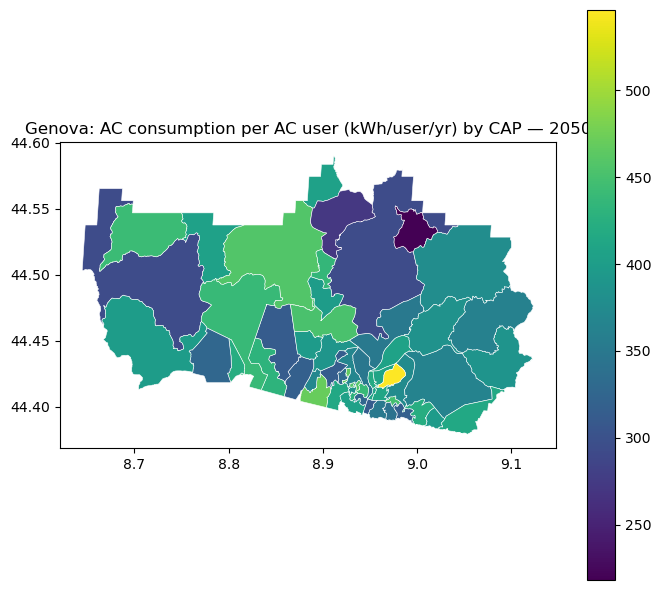

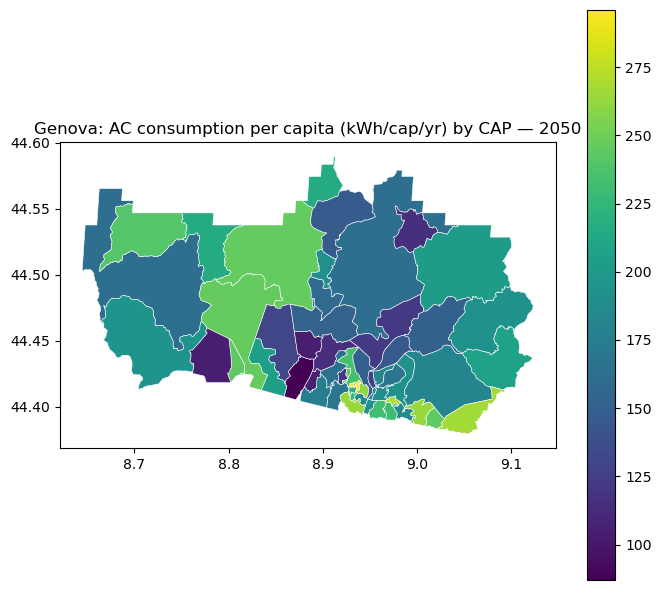

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_cap_ac_consumption_summary.csv
Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_cap_ac_consumption_map.geojson


In [9]:
per_user_map_by_year = {}
kwh_tot_map_by_year = {}
cap_per_user_by_year = {}
cap_energy_by_year = {}
city_summary_rows = []

for year in years_interest:
    print(f"\n=== Year {year} ===")

    # inputs for this year
    coverage_map = _cov_for_year(year) # AC penetration map
    H_year = _get_H_for_year(year) # hazard index
    per_user_city = float(per_user_city_by_year[year]) # kWh per AC user (city)

    # citywide AC share from the map
    m = CITY_MASK & np.isfinite(coverage_map) & np.isfinite(pop_grid)
    ac_city_map = float(np.nansum(coverage_map[m] * pop_grid[m]) / np.nansum(pop_grid[m]))

    # target AC share from NB5, if available
    if "ac_city_by_year" in globals() and year in ac_city_by_year:
        ac_city_target = float(ac_city_by_year[year])
    else:
        ac_city_target = ac_city_map

    print(f"AC share from map (city pop-weighted): {ac_city_map:.3f}")
    print(f"AC share from NB5 (target): {ac_city_target:.3f}")

    # CAP-level hazard index (pop-weighted) for dispersion
    CAP_PIX = CITY_MASK & np.isfinite(H_year) & (cap_ids > 0)
    valid = CAP_PIX & np.isfinite(pop_grid)

    dfH = pd.DataFrame({
        "cap_id": cap_ids[valid].ravel().astype(int),
        "pop": pop_grid[valid].ravel().astype(float),
        "H": H_year[valid].ravel().astype(float),
    })

    cap_H = (dfH.groupby("cap_id").apply(_wavg_pop)
             .reset_index(name="H_cap")
             .sort_values("cap_id")
             .reset_index(drop=True))

    H_city = (float(np.average(dfH["H"], weights=dfH["pop"])) if dfH["pop"].sum() > 0 else float(dfH["H"].mean()))

    # fixed eps per CAP (same CAP is always "high" or "low" across years)
    eps = cap_H["cap_id"].map(eps_by_cap).to_numpy(float)

    cap_draws = cap_H.copy()
    ratio = np.clip((cap_draws["H_cap"].to_numpy() / max(H_city, 1e-6)), 0.25, 4.0) # spread around the city mean, proportional to local heat

    sigma_cap = sigma0 * (ratio ** gamma) * per_user_city
    draws = per_user_city + sigma_cap * eps
    draws = np.clip(draws, 0.0, np.inf)
    cap_draws["per_user_CAP_raw"] = draws.astype("float32")

    # paint to grid (cap_id -> kWh/user)
    lut = np.full(int(cap_ref["cap_id"].max()) + 1, np.nan, dtype="float32")
    lut[cap_draws["cap_id"].to_numpy()] = cap_draws["per_user_CAP_raw"].to_numpy()

    per_user_map = np.full(ref_data.shape, np.nan, dtype="float32")
    per_user_map[CAP_PIX] = lut[cap_ids[CAP_PIX]]

    # scale so that users-weighted city mean equals per_user_city exactly
    w_users = (coverage_map * pop_grid) * CITY_MASK
    num = np.nansum(per_user_map * w_users)
    den = np.nansum(w_users)
    k = float(per_user_city) / (num / den) if den > 0 else 1.0
    per_user_map *= k

    # totals
    kwh_pc_map = per_user_map * coverage_map
    kwh_tot_map = kwh_pc_map * pop_grid

    # CAP table after scaling
    cap_draws["per_user_CAP"] = cap_draws["per_user_CAP_raw"] * k
    cap_per_user = (cap_draws[["cap_id","per_user_CAP"]]
                    .rename(columns={"per_user_CAP": "kwh_per_user_cap"}))

    # diagnostics
    per_user_mean_city = float(np.nansum(per_user_map * w_users) / np.nansum(w_users)) if den > 0 else np.nan
    ac_share_from_map = float(np.nansum(w_users) / np.nansum(pop_grid[CITY_MASK]))
    city_total_gwh = float(np.nansum(kwh_tot_map[CITY_MASK]) / 1e6)
    print("Per-user mean (city):", per_user_mean_city)
    print("AC share from map: ", ac_share_from_map)
    print("City total GWh: ", city_total_gwh)

    # CAP aggregation for reporting
    dfE = pd.DataFrame({
        "cap_id": cap_ids[CITY_MASK].ravel().astype(int),
        "pop": pop_grid[CITY_MASK].ravel().astype(float),
        "kwh": kwh_tot_map[CITY_MASK].ravel().astype(float),
    })
    dfE = dfE[dfE["cap_id"] > 0]

    cap_energy = (dfE.groupby("cap_id")
                  .agg(pop_cap=("pop","sum"), kwh_cap=("kwh","sum"))
                  .reset_index())
    cap_energy["kwh_pc_overall"] = cap_energy["kwh_cap"] / cap_energy["pop_cap"]

    cap_per_user["year"] = year
    cap_energy["year"] = year

    per_user_map_by_year[year] = per_user_map
    kwh_tot_map_by_year[year] = kwh_tot_map
    cap_per_user_by_year[year] = cap_per_user
    cap_energy_by_year[year] = cap_energy

    city_summary_rows.append({
        "year": year,
        "ac_share_city": ac_city_target,
        "ac_share_from_map": ac_share_from_map,
        "per_user_city_input": per_user_city,
        "per_user_city_realized": per_user_mean_city,
        "city_total_GWh": city_total_gwh,
    })

city_summary = pd.DataFrame(city_summary_rows)
display(city_summary)

# CAP-level consumption tables and maps over multiple years
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

years_maps = [2030, 2040, 2050]
pop_grid = pop_on_ref
cap_ids = cap_on_ref

def show_rank(df, col, k=15, title=""):
    cols = ["cap_id","ac_share_cap","kwh_per_user_cap","pop_cap","kwh_cap","kwh_pc_overall","year"]
    top = df[cols].sort_values(col, ascending=False).head(k).reset_index(drop=True)
    bot = df[cols].sort_values(col, ascending=True).head(k).reset_index(drop=True)
    print(f"\nTop {k} CAPs by {col} — {title}"); display(top)
    print(f"Bottom {k} CAPs by {col} — {title}"); display(bot)

all_cap_tbl = []
all_cap_map = []

for year_map in years_maps:
    print(f"\n==== CAP-level results for year {year_map} ====")

    coverage_map = _cov_for_year(year_map)
    per_user_map = per_user_map_by_year[year_map]
    kwh_tot_map = kwh_tot_map_by_year[year_map]
    cap_per_user = cap_per_user_by_year[year_map]

    # matched pixel universe: within city, with CAP, and finite for all needed layers
    CAP_PIX = (CITY_MASK & (cap_ids > 0) & np.isfinite(pop_grid) & np.isfinite(coverage_map) & np.isfinite(kwh_tot_map))

    # users and pop by CAP
    df_cap_base = pd.DataFrame({
        "cap_id": cap_ids[CAP_PIX].ravel().astype(int),
        "pop": pop_grid[CAP_PIX].ravel().astype(float),
        "users": (coverage_map[CAP_PIX] * pop_grid[CAP_PIX]).ravel().astype(float),
    })
    cap_pop_users = (df_cap_base.groupby("cap_id", as_index=False)
                     .agg(pop_cap=("pop","sum"), users_cap=("users","sum")))
    cap_pop_users["ac_share_cap"] = np.where(cap_pop_users["pop_cap"] > 0, cap_pop_users["users_cap"] / cap_pop_users["pop_cap"], np.nan)

    # energy totals by CAP (sum of pixel kWh)
    df_kwh = pd.DataFrame({
        "cap_id": cap_ids[CAP_PIX].ravel().astype(int),
        "kwh": kwh_tot_map[CAP_PIX].ravel().astype(float),
    })
    cap_energy = (df_kwh.groupby("cap_id", as_index=False)
                  .agg(kwh_cap=("kwh","sum")))

    # merge and compute per-capita
    cap_tbl = (cap_pop_users
               .merge(cap_energy, on="cap_id", how="left")
               .merge(cap_per_user, on="cap_id", how="left"))
    cap_tbl["kwh_pc_overall"] = np.where(cap_tbl["pop_cap"] > 0, cap_tbl["kwh_cap"] / cap_tbl["pop_cap"], np.nan)
    cap_tbl["year"] = year_map
    all_cap_tbl.append(cap_tbl)

    # city checks on the same matched universe
    city_pop = float(np.nansum(pop_grid[CAP_PIX]))
    city_users = float(np.nansum((coverage_map * pop_grid)[CAP_PIX]))
    city_kwh_GWh = float(np.nansum(kwh_tot_map[CAP_PIX])) / 1e6
    per_user_mean_city = float(
        np.nansum(cap_tbl["kwh_per_user_cap"] * cap_tbl["users_cap"]) / max(city_users, 1e-12)
    )
    print(f"City pop: {city_pop:,.0f}")
    print(f"City AC users: {city_users:,.0f} (AC share ≈ {city_users/city_pop:.3f})")
    print(f"City total AC electricity: {city_kwh_GWh:.3f} GWh/yr")
    print(f"City per-AC-user mean (users-weighted): {per_user_mean_city:.6f} kWh/user/yr")

    # ranks for this year
    show_rank(cap_tbl, "kwh_pc_overall", k=10, title=f"kWh per capita (overall), {year_map}")
    show_rank(cap_tbl, "kwh_cap", k=10, title=f"Total kWh, {year_map}")

    # join to CAP polygons (cap_4326 loaded earlier)
    cap_map = cap_4326.merge(cap_tbl, on="cap_id", how="left")
    cap_map["year"] = year_map
    cap_map_4326 = cap_map.to_crs("EPSG:4326")
    all_cap_map.append(cap_map_4326)

    # maps for this year
    fig, ax = plt.subplots(1, 1, figsize=(7,6))
    cap_map_4326.plot(ax=ax, column="kwh_per_user_cap", legend=True, linewidth=0.4, edgecolor="white")
    ax.set_title(f"{CITY}: AC consumption per AC user (kWh/user/yr) by CAP — {year_map}")
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(7,6))
    cap_map_4326.plot(ax=ax, column="kwh_pc_overall", legend=True, linewidth=0.4, edgecolor="white")
    ax.set_title(f"{CITY}: AC consumption per capita (kWh/cap/yr) by CAP — {year_map}")
    plt.tight_layout(); plt.show()

# save all years together
OUT = Path(OUT); OUT.mkdir(parents=True, exist_ok=True)

cap_tbl_all = pd.concat(all_cap_tbl, ignore_index=True)
cap_tbl_all["kwh_GWh"] = cap_tbl_all["kwh_cap"] / 1e6
cap_tbl_csv = OUT / f"{SLUG}_cap_ac_consumption_summary.csv"
cap_tbl_all.to_csv(cap_tbl_csv, index=False)

cap_map_all = gpd.GeoDataFrame(pd.concat(all_cap_map, ignore_index=True), crs="EPSG:4326")
cap_geojson = OUT / f"{SLUG}_cap_ac_consumption_map.geojson"
(cap_map_all[["cap_id","geometry","year", "kwh_per_user_cap","ac_share_cap","kwh_pc_overall","kwh_cap"]]
 .to_file(cap_geojson, driver="GeoJSON"))

print("Saved:", cap_tbl_csv)
print("Saved:", cap_geojson)

And as we said, we downscaled the **electricity consumption to the the CAPs level** 

**Aggregation at the Municipio level**


==== Municipio-level results for year 2030 ====
City diagnostics by universe:
[ALL FUA] per-user=523.569479 AC-share=0.426 total=128.677 GWh pop=576,550 users=245,769
[Municipi-only (muni_on_ref>0)] per-user=527.753697 AC-share=0.423 total=120.551 GWh pop=539,994 users=228,423
[Outside Municipi (muni_id==0)] per-user=468.471587 AC-share=0.475 total=8.126 GWh pop=36,556 users=17,347

Check: in + out should equal all
users: 245769.39453125 vs 245769.40625
GWh:  128.6773655 vs 128.67736

From groupby (includes muni_id=0):
Users-weighted per-user mean (city): 523.569553715731
City total GWh: 128.67736820824706

Top 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,2,0.515870,541.728664,67664.634250,1.890966e+07,279.461441,2030
1,4,0.532931,524.019017,66699.290064,1.862685e+07,279.266094,2030
2,6,0.567211,489.597031,70074.904773,1.946013e+07,277.704689,2030
3,1,0.384318,571.876138,45902.595959,1.008858e+07,219.782284,2030
4,8,0.389311,526.800384,51797.884639,1.062319e+07,205.089216,2030
5,3,0.351035,562.374275,52716.844678,1.040699e+07,197.412927,2030
6,7,0.357362,504.231283,70396.979866,1.268505e+07,180.193146,2030
7,5,0.341158,510.219262,54548.316624,9.494984e+06,174.065567,2030
8,9,0.302910,565.221029,59900.125892,1.025557e+07,171.211170,2030


Bottom 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,9,0.302910,565.221029,59900.125892,1.025557e+07,171.211170,2030
1,5,0.341158,510.219262,54548.316624,9.494984e+06,174.065567,2030
2,7,0.357362,504.231283,70396.979866,1.268505e+07,180.193146,2030
3,3,0.351035,562.374275,52716.844678,1.040699e+07,197.412927,2030
4,8,0.389311,526.800384,51797.884639,1.062319e+07,205.089216,2030
5,1,0.384318,571.876138,45902.595959,1.008858e+07,219.782284,2030
6,6,0.567211,489.597031,70074.904773,1.946013e+07,277.704689,2030
7,4,0.532931,524.019017,66699.290064,1.862685e+07,279.266094,2030
8,2,0.515870,541.728664,67664.634250,1.890966e+07,279.461441,2030



Top 10 Municipi by kwh_muni — Total kWh, 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.567211,489.597031,70074.904773,1.946013e+07,277.704689,2030
1,2,0.515870,541.728664,67664.634250,1.890966e+07,279.461441,2030
2,4,0.532931,524.019017,66699.290064,1.862685e+07,279.266094,2030
3,7,0.357362,504.231283,70396.979866,1.268505e+07,180.193146,2030
4,8,0.389311,526.800384,51797.884639,1.062319e+07,205.089216,2030
5,3,0.351035,562.374275,52716.844678,1.040699e+07,197.412927,2030
6,9,0.302910,565.221029,59900.125892,1.025557e+07,171.211170,2030
7,1,0.384318,571.876138,45902.595959,1.008858e+07,219.782284,2030
8,5,0.341158,510.219262,54548.316624,9.494984e+06,174.065567,2030


Bottom 10 Municipi by kwh_muni — Total kWh, 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,5,0.341158,510.219262,54548.316624,9.494984e+06,174.065567,2030
1,1,0.384318,571.876138,45902.595959,1.008858e+07,219.782284,2030
2,9,0.302910,565.221029,59900.125892,1.025557e+07,171.211170,2030
3,3,0.351035,562.374275,52716.844678,1.040699e+07,197.412927,2030
4,8,0.389311,526.800384,51797.884639,1.062319e+07,205.089216,2030
5,7,0.357362,504.231283,70396.979866,1.268505e+07,180.193146,2030
6,4,0.532931,524.019017,66699.290064,1.862685e+07,279.266094,2030
7,2,0.515870,541.728664,67664.634250,1.890966e+07,279.461441,2030
8,6,0.567211,489.597031,70074.904773,1.946013e+07,277.704689,2030


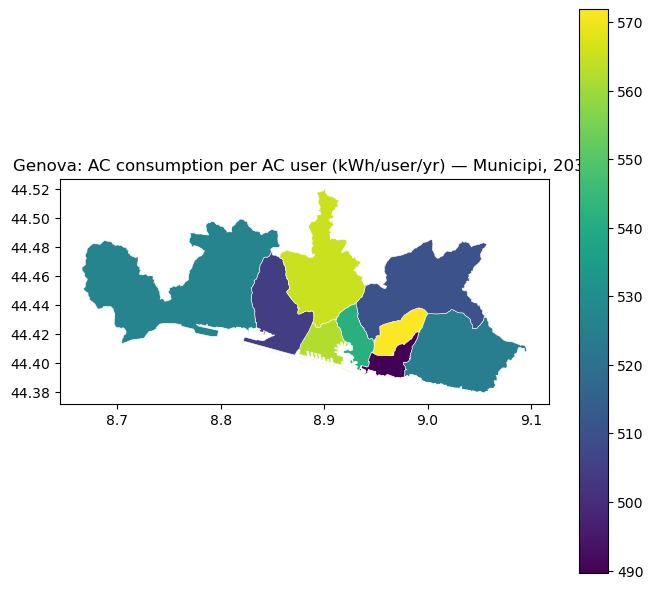

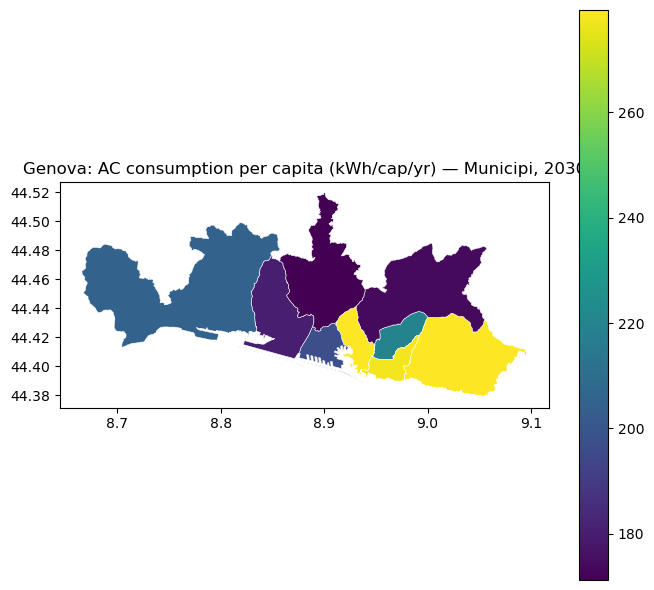


==== Municipio-level results for year 2040 ====
City diagnostics by universe:
[ALL FUA] per-user=523.569479 AC-share=0.426 total=128.677 GWh pop=576,550 users=245,769
[Municipi-only (muni_on_ref>0)] per-user=527.751070 AC-share=0.423 total=120.550 GWh pop=539,994 users=228,423
[Outside Municipi (muni_id==0)] per-user=468.506551 AC-share=0.475 total=8.127 GWh pop=36,556 users=17,347

Check: in + out should equal all
users: 245769.39453125 vs 245769.40625
GWh:  128.677372 vs 128.67736

From groupby (includes muni_id=0):
Users-weighted per-user mean (city): 523.5695632687405
City total GWh: 128.67736965594656

Top 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,2,0.515870,541.747884,67664.634250,1.891033e+07,279.471349,2040
1,4,0.532931,524.064638,66699.290064,1.862847e+07,279.290413,2040
2,6,0.567211,489.566008,70074.904773,1.945890e+07,277.687097,2040
3,1,0.384318,571.870905,45902.595959,1.008849e+07,219.780275,2040
4,8,0.389311,526.791841,51797.884639,1.062301e+07,205.085883,2040
5,3,0.351035,562.340033,52716.844678,1.040635e+07,197.400900,2040
6,7,0.357362,504.229550,70396.979866,1.268501e+07,180.192525,2040
7,5,0.341158,510.222852,54548.316624,9.495050e+06,174.066790,2040
8,9,0.302910,565.177572,59900.125892,1.025478e+07,171.198005,2040


Bottom 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,9,0.302910,565.177572,59900.125892,1.025478e+07,171.198005,2040
1,5,0.341158,510.222852,54548.316624,9.495050e+06,174.066790,2040
2,7,0.357362,504.229550,70396.979866,1.268501e+07,180.192525,2040
3,3,0.351035,562.340033,52716.844678,1.040635e+07,197.400900,2040
4,8,0.389311,526.791841,51797.884639,1.062301e+07,205.085883,2040
5,1,0.384318,571.870905,45902.595959,1.008849e+07,219.780275,2040
6,6,0.567211,489.566008,70074.904773,1.945890e+07,277.687097,2040
7,4,0.532931,524.064638,66699.290064,1.862847e+07,279.290413,2040
8,2,0.515870,541.747884,67664.634250,1.891033e+07,279.471349,2040



Top 10 Municipi by kwh_muni — Total kWh, 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.567211,489.566008,70074.904773,1.945890e+07,277.687097,2040
1,2,0.515870,541.747884,67664.634250,1.891033e+07,279.471349,2040
2,4,0.532931,524.064638,66699.290064,1.862847e+07,279.290413,2040
3,7,0.357362,504.229550,70396.979866,1.268501e+07,180.192525,2040
4,8,0.389311,526.791841,51797.884639,1.062301e+07,205.085883,2040
5,3,0.351035,562.340033,52716.844678,1.040635e+07,197.400900,2040
6,9,0.302910,565.177572,59900.125892,1.025478e+07,171.198005,2040
7,1,0.384318,571.870905,45902.595959,1.008849e+07,219.780275,2040
8,5,0.341158,510.222852,54548.316624,9.495050e+06,174.066790,2040


Bottom 10 Municipi by kwh_muni — Total kWh, 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,5,0.341158,510.222852,54548.316624,9.495050e+06,174.066790,2040
1,1,0.384318,571.870905,45902.595959,1.008849e+07,219.780275,2040
2,9,0.302910,565.177572,59900.125892,1.025478e+07,171.198005,2040
3,3,0.351035,562.340033,52716.844678,1.040635e+07,197.400900,2040
4,8,0.389311,526.791841,51797.884639,1.062301e+07,205.085883,2040
5,7,0.357362,504.229550,70396.979866,1.268501e+07,180.192525,2040
6,4,0.532931,524.064638,66699.290064,1.862847e+07,279.290413,2040
7,2,0.515870,541.747884,67664.634250,1.891033e+07,279.471349,2040
8,6,0.567211,489.566008,70074.904773,1.945890e+07,277.687097,2040


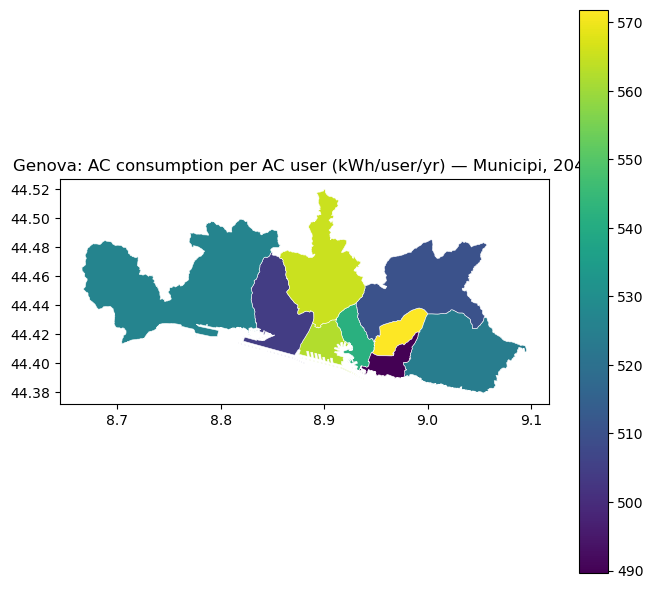

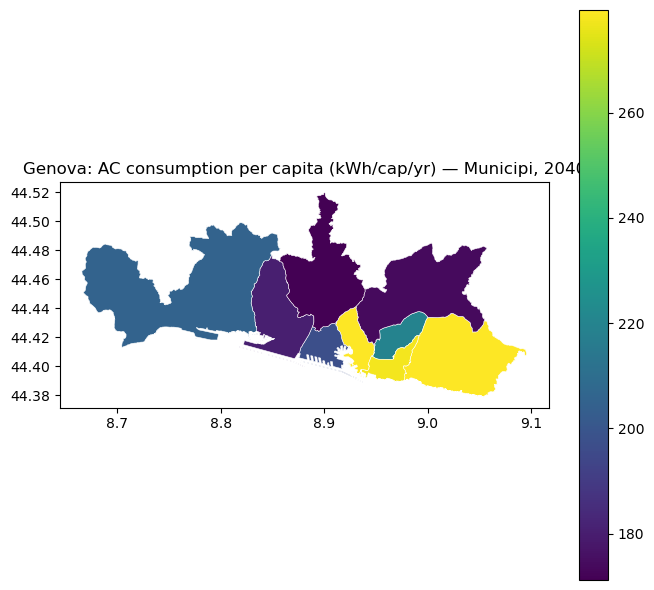


==== Municipio-level results for year 2050 ====
City diagnostics by universe:
[ALL FUA] per-user=382.303361 AC-share=0.470 total=103.525 GWh pop=576,550 users=270,792
[Municipi-only (muni_on_ref>0)] per-user=385.358772 AC-share=0.466 total=96.976 GWh pop=539,994 users=251,651
[Outside Municipi (muni_id==0)] per-user=342.133372 AC-share=0.524 total=6.549 GWh pop=36,556 users=19,141

Check: in + out should equal all
users: 270791.857421875 vs 270791.84375
GWh:  103.52463300000001 vs 103.524632

From groupby (includes muni_id=0):
Users-weighted per-user mean (city): 382.30334908940665
City total GWh: 103.52463172718426

Top 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,2,0.569589,395.633109,67664.634250,1.524812e+07,225.348416,2050
1,4,0.588618,382.734670,66699.290064,1.502632e+07,225.284593,2050
2,6,0.626851,357.436413,70074.904773,1.570093e+07,224.059196,2050
3,1,0.422868,417.484075,45902.595959,8.103680e+06,176.540788,2050
4,8,0.428437,384.820493,51797.884639,8.539989e+06,164.871386,2050
5,3,0.385747,410.524648,52716.844678,8.348173e+06,158.358734,2050
6,7,0.392804,368.319940,70396.979866,1.018487e+07,144.677593,2050
7,5,0.374732,372.549682,54548.316624,7.615287e+06,139.606262,2050
8,9,0.332073,412.666065,59900.125892,8.208437e+06,137.035383,2050


Bottom 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,9,0.332073,412.666065,59900.125892,8.208437e+06,137.035383,2050
1,5,0.374732,372.549682,54548.316624,7.615287e+06,139.606262,2050
2,7,0.392804,368.319940,70396.979866,1.018487e+07,144.677593,2050
3,3,0.385747,410.524648,52716.844678,8.348173e+06,158.358734,2050
4,8,0.428437,384.820493,51797.884639,8.539989e+06,164.871386,2050
5,1,0.422868,417.484075,45902.595959,8.103680e+06,176.540788,2050
6,6,0.626851,357.436413,70074.904773,1.570093e+07,224.059196,2050
7,4,0.588618,382.734670,66699.290064,1.502632e+07,225.284593,2050
8,2,0.569589,395.633109,67664.634250,1.524812e+07,225.348416,2050



Top 10 Municipi by kwh_muni — Total kWh, 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.626851,357.436413,70074.904773,1.570093e+07,224.059196,2050
1,2,0.569589,395.633109,67664.634250,1.524812e+07,225.348416,2050
2,4,0.588618,382.734670,66699.290064,1.502632e+07,225.284593,2050
3,7,0.392804,368.319940,70396.979866,1.018487e+07,144.677593,2050
4,8,0.428437,384.820493,51797.884639,8.539989e+06,164.871386,2050
5,3,0.385747,410.524648,52716.844678,8.348173e+06,158.358734,2050
6,9,0.332073,412.666065,59900.125892,8.208437e+06,137.035383,2050
7,1,0.422868,417.484075,45902.595959,8.103680e+06,176.540788,2050
8,5,0.374732,372.549682,54548.316624,7.615287e+06,139.606262,2050


Bottom 10 Municipi by kwh_muni — Total kWh, 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,5,0.374732,372.549682,54548.316624,7.615287e+06,139.606262,2050
1,1,0.422868,417.484075,45902.595959,8.103680e+06,176.540788,2050
2,9,0.332073,412.666065,59900.125892,8.208437e+06,137.035383,2050
3,3,0.385747,410.524648,52716.844678,8.348173e+06,158.358734,2050
4,8,0.428437,384.820493,51797.884639,8.539989e+06,164.871386,2050
5,7,0.392804,368.319940,70396.979866,1.018487e+07,144.677593,2050
6,4,0.588618,382.734670,66699.290064,1.502632e+07,225.284593,2050
7,2,0.569589,395.633109,67664.634250,1.524812e+07,225.348416,2050
8,6,0.626851,357.436413,70074.904773,1.570093e+07,224.059196,2050


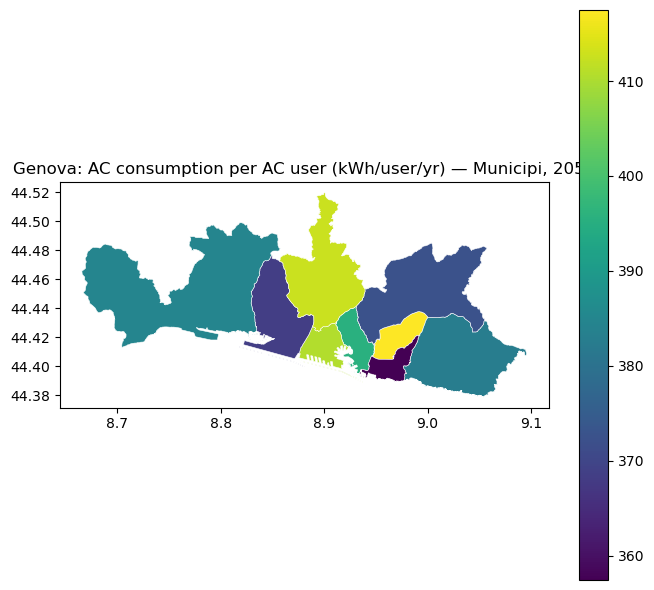

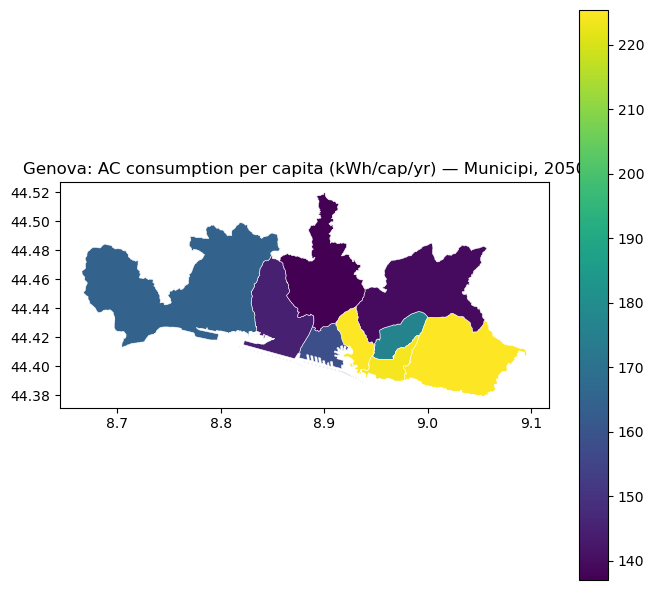

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_muni_ac_consumption_summary.csv
Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_muni_ac_consumption_map.geojson


In [10]:
# Municipio-level AC electricity: per-user, per-capita, totals over multiple years
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

years_maps = [2030, 2040, 2050]
assert 'muni_on_ref' in globals(), "muni_on_ref raster missing."
assert 'muni' in globals() and isinstance(muni, gpd.GeoDataFrame), "muni GeoDataFrame missing."

pop_grid = pop_on_ref

def _wavg(x, w):
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    s = np.nansum(w)
    return float(np.nansum(x * w) / s) if s > 0 else np.nan

def show_rank_muni(df_in, col, k=10, title=""):
    cols = ["muni_id","ac_share_muni","kwh_per_user_muni", "pop_muni","kwh_muni","kwh_pc_overall","year"]
    top = df_in[cols].sort_values(col, ascending=False).head(k).reset_index(drop=True)
    bot = df_in[cols].sort_values(col, ascending=True).head(k).reset_index(drop=True)
    print(f"\nTop {k} Municipi by {col} — {title}"); display(top)
    print(f"Bottom {k} Municipi by {col} — {title}"); display(bot)

all_muni_tbl = []
all_muni_map = []

for year_map in years_maps:
    print(f"\n==== Municipio-level results for year {year_map} ====")

    coverage_map = _cov_for_year(year_map)
    per_user_map = per_user_map_by_year[year_map]
    kwh_tot_map = kwh_tot_map_by_year[year_map]

    def city_diag(mask, label):
        users = float(np.nansum((coverage_map * pop_grid)[mask]))
        per_user = float(np.nansum((per_user_map * coverage_map * pop_grid)[mask]) / max(users, 1e-12))
        kwh = float(np.nansum(kwh_tot_map[mask])) / 1e6
        pop = float(np.nansum(pop_grid[mask]))
        print(f"[{label}] per-user={per_user:.6f} AC-share={users/pop:.3f} "
              f"total={kwh:.3f} GWh pop={pop:,.0f} users={users:,.0f}")
        return per_user, users, kwh

    # universes (keep id==0 as "outside" bucket)
    mask_all = CITY_MASK
    mask_in = CITY_MASK & (muni_on_ref > 0)
    mask_out = CITY_MASK & (muni_on_ref == 0)

    print("City diagnostics by universe:")
    pu_all, u_all, k_all = city_diag(mask_all, "ALL FUA")
    pu_in, u_in, k_in = city_diag(mask_in, "Municipi-only (muni_on_ref>0)")
    pu_out, u_out, k_out = city_diag(mask_out, "Outside Municipi (muni_id==0)")

    print("\nCheck: in + out should equal all")
    print("users:", u_in + u_out, "vs", u_all)
    print("GWh: ", k_in + k_out, "vs", k_all)

    # Build pixel to Municipio table over the full city mask (includes muni_id==0)
    valid_all = (CITY_MASK & np.isfinite(per_user_map) & np.isfinite(kwh_tot_map) & np.isfinite(pop_grid) & np.isfinite(coverage_map))
    df = pd.DataFrame({
        "muni_id": muni_on_ref[valid_all].ravel().astype(int), # includes 0
        "pop": pop_grid[valid_all].ravel().astype(float),
        "users": (coverage_map[valid_all] * pop_grid[valid_all]).ravel().astype(float),
        "kwh": kwh_tot_map[valid_all].ravel().astype(float),
        "per_user": per_user_map[valid_all].ravel().astype(float),
    })

    # users-weighted per-user by municipio
    per_user_by_muni = (df.groupby("muni_id")
                        .apply(lambda g: _wavg(g["per_user"], g["users"]))
                        .reset_index(name="kwh_per_user_muni"))

    # totals by municipio
    muni_tbl_all = (df.groupby("muni_id", as_index=False)
                    .agg(pop_muni=("pop","sum"), users_muni=("users","sum"), kwh_muni=("kwh","sum"))
                    .merge(per_user_by_muni, on="muni_id", how="left"))

    # rates
    muni_tbl_all["ac_share_muni"] = np.where(muni_tbl_all["pop_muni"] > 0, muni_tbl_all["users_muni"] / muni_tbl_all["pop_muni"], np.nan)
    muni_tbl_all["kwh_pc_overall"] = np.where(muni_tbl_all["pop_muni"] > 0, muni_tbl_all["kwh_muni"] / muni_tbl_all["pop_muni"], np.nan)
    muni_tbl_all["year"] = year_map
    all_muni_tbl.append(muni_tbl_all)

    # city diagnostics from grouped table
    users_sum = float(muni_tbl_all["users_muni"].sum())
    per_user_from_groups = float(
        np.nansum(muni_tbl_all["kwh_per_user_muni"] * muni_tbl_all["users_muni"]) / max(users_sum, 1e-12)
    )
    kwh_sum = float(muni_tbl_all["kwh_muni"].sum()) / 1e6
    print("\nFrom groupby (includes muni_id=0):")
    print("Users-weighted per-user mean (city):", per_user_from_groups)
    print("City total GWh:", kwh_sum)

    # tables and maps for Municipi only (exclude id==0 for reporting)
    muni_only = muni_tbl_all[muni_tbl_all["muni_id"] > 0].copy()
    show_rank_muni(muni_only, "kwh_pc_overall", k=10, title=f"kWh per capita (overall), {year_map}")
    show_rank_muni(muni_only, "kwh_muni", k=10, title=f"Total kWh, {year_map}")

    # map join
    muni_map = (muni[["muni_id","muni_name","geometry"]] if "muni_name" in muni.columns else muni[["muni_id","geometry"]]).merge(muni_only, on="muni_id", how="left")
    muni_map["year"] = year_map
    muni_map_4326 = muni_map.to_crs("EPSG:4326")
    all_muni_map.append(muni_map_4326)

    fig, ax = plt.subplots(1,1, figsize=(7,6))
    muni_map_4326.plot(ax=ax, column="kwh_per_user_muni", legend=True, linewidth=0.4, edgecolor="white")
    ax.set_title(f"{CITY}: AC consumption per AC user (kWh/user/yr) — Municipi, {year_map}")
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(1,1, figsize=(7,6))
    muni_map_4326.plot(ax=ax, column="kwh_pc_overall", legend=True, linewidth=0.4, edgecolor="white")
    ax.set_title(f"{CITY}: AC consumption per capita (kWh/cap/yr) — Municipi, {year_map}")
    plt.tight_layout(); plt.show()

# saving all years together
OUT = Path(OUT); OUT.mkdir(parents=True, exist_ok=True)

muni_tbl_all_years = pd.concat(all_muni_tbl, ignore_index=True)
muni_csv = OUT / f"{SLUG}_muni_ac_consumption_summary.csv"
(muni_tbl_all_years
 .assign(kwh_GWh=lambda d: d["kwh_muni"]/1e6)
 .to_csv(muni_csv, index=False))

muni_map_all = gpd.GeoDataFrame(pd.concat(all_muni_map, ignore_index=True), crs="EPSG:4326")
muni_geo = OUT / f"{SLUG}_muni_ac_consumption_map.geojson"
(muni_map_all[["muni_id","geometry","year", "kwh_per_user_muni","ac_share_muni","kwh_pc_overall","kwh_muni"]]
 .to_file(muni_geo, driver="GeoJSON"))

print("Saved:", muni_csv)
print("Saved:", muni_geo)

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Why do the maps per AC user and per capita look different? Because the denominator is not the same. Per-AC_user varies because we draw CAP-level kWh/user around the city mean and scale it to match the city target. The map reflects only usage among households that have AC while the per-capita divides this same energy across everyone in the CAP. It equals AC share*per-AC-user. So places with low ownership look much lower per-capita even if users there consume a lot. Conversely, places with high ownership look high even if users don't consume unusually much. Finally, about the Municipi vs CAP, municipio values are population-weighted aggregates of the CAPs inside them. Rankings of totals differ because total kWh = per-capita * population. 
</blockquote>